<a href="https://colab.research.google.com/github/sarabadrr/lab5/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gaussian noisy MSE: 0.005062705929729816
Mean filter MSE: 0.0038636380976249116
Geometric mean MSE: 0.006921665594450988
Impulse noisy MSE: 0.025283813
Median filter MSE: 0.0002899169921875


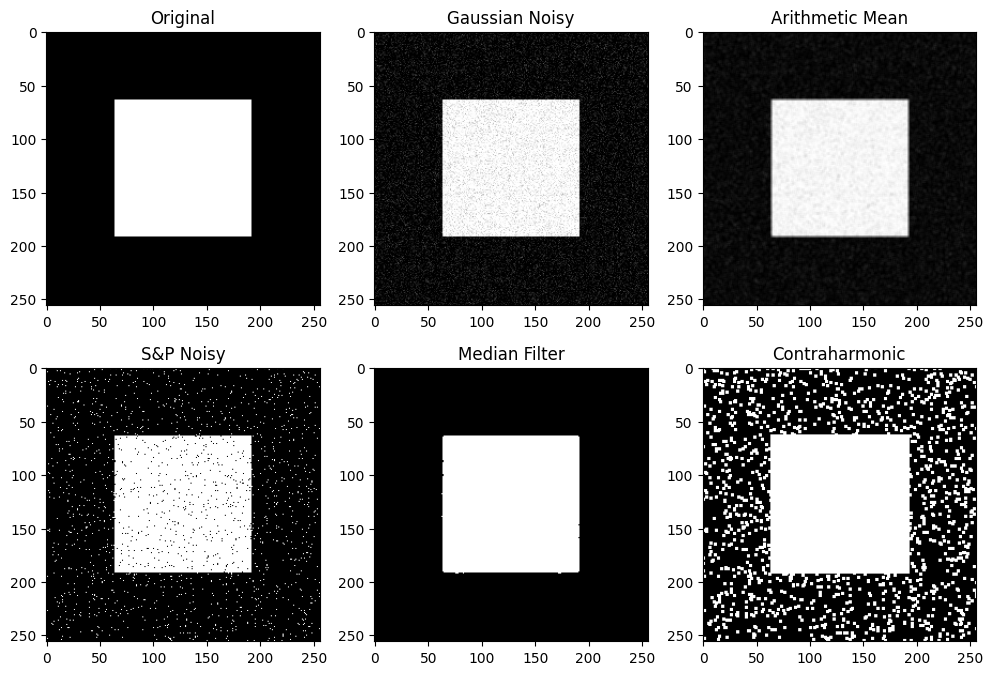

In [92]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Start with a clean greyscale image (Task 1)
img = np.zeros((256, 256), dtype=np.float32)
img[64:192, 64:192] = 1.0  # White square

# Define the MSE function as per starter evaluation
def mse(img1, img2):
    return np.mean((img1 - img2)**2)

# 2. Gaussian noise and removal (Task 2)
g = np.clip(img + np.random.normal(0, 0.1, img.shape), 0, 1)
mean3 = cv2.blur(g, (3, 3)) # Arithmetic Mean
geo3 = np.exp(cv2.blur(np.log(g + 1e-6), (3, 3))) # Geometric Mean

# 3. Salt and pepper noise and removal (Task 3)
sp = img.copy()
prob = 0.05
mask = np.random.random(img.shape)
sp[mask < prob/2] = 0.0
sp[mask > 1 - prob/2] = 1.0

# Median filter
med3 = cv2.medianBlur((sp * 255).astype(np.uint8), 3) / 255.0

# Contraharmonic filter (Must be present as a core component)
Q = 1.5
num = np.power(sp + 1e-6, Q + 1)
den = np.power(sp + 1e-6, Q)
contraharmonic = cv2.filter2D(num, -1, np.ones((3,3))) / cv2.filter2D(den, -1, np.ones((3,3)))

# 4. Starter evaluation (Requirement 4)
# Keep these exact print statements
print("Gaussian noisy MSE:", mse(img, g))
print("Mean filter MSE:", mse(img, mean3))
print("Geometric mean MSE:", mse(img, geo3))
print("Impulse noisy MSE:", mse(img, sp))
print("Median filter MSE:", mse(img, med3))

# Display results
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(img, 'gray'), plt.title('Original')
plt.subplot(232), plt.imshow(g, 'gray'), plt.title('Gaussian Noisy')
plt.subplot(233), plt.imshow(mean3, 'gray'), plt.title('Arithmetic Mean')
plt.subplot(234), plt.imshow(sp, 'gray'), plt.title('S&P Noisy')
plt.subplot(235), plt.imshow(med3, 'gray'), plt.title('Median Filter')
plt.subplot(236), plt.imshow(contraharmonic, 'gray'), plt.title('Contraharmonic')
plt.show()



Reflection Question

Why is restoration more objective than enhancement?	Restoration uses math to revert an image back to a known original, we can measure success with MSE, enhancement is just making it look better, which depends on human opinion.
Why must noise models be identified first?	Because filters are specific, a mean filter on salt & pepper noise just blurs the dots into gray smudges instead of removing them, u need the right tool for the specific noise.
Why is there no single best denoising filter?	every filter removes some good detail while removing bad noise, the best choice depends on whether you care more about sharpness or cleanliness